# Chinese world — per-polity (Cultura) vs per-raw-token (Cross-Verified)

Side-by-side comparison of the labels carried by each database for the Chinese world. Each row pairs the **Cultura polity** label(s) with the equivalent **Cross-Verified `string_citizenship_raw_d` token(s)**, in chronological order. Counts are exact integers (number of distinct individuals). Every Cultura polity that maps to PRC or Taiwan in `polities_modern_countries_cliopatria`, plus every Chinese-world raw token observed in CV, is shown — even when the other side is empty (`—`).

Two totals at the bottom:
- **Sum across rows** (an individual can appear in several rows because polity_name is a `;`-separated list, so this sum can overlap).
- **Total unique individuals** (set-union over all rows on each side).

In [ ]:
import duckdb
import re
import time
import polars as pl

DB_PATH = '../data/humans_clean.duckdb'
CV_PATH = '../data/similar_databases/cross-verified-database/cross-verified-database.utf8.csv.gz'

## 1. Pairing — Cultura polity ↔ CV raw token, in chronological order

A `Cultura` cell can list several polities (their union of individuals is counted). A `CV` cell can list several raw tokens (their union of individuals is counted). `None` on either side means the database has no equivalent label.

In [2]:
# Unified ordered list of entries. Each entry = (cultura_polity_or_None, [cv_tokens]).
# - When cultura_polity is None, the row(s) are CV-only (Cliopatria cells blank).
# - When cv_tokens has multiple entries, they are emitted on consecutive rows;
#   the Cultura columns are filled only on the first row of the block.
# Order is chronological/regional. CV-only tokens are inserted at their own
# chronological position so the bottom of the table doesn't accumulate them.
ENTRIES = [
    (None,                                                 ['Xia_dynasty']),
    ('Shang Dynasty',                                      ['Shang_dynasty']),
    ('Zhou Dynasty',                                       ['Western_Zhou', 'Zhou_dynasty']),
    ('Spring and Autumn States',                           []),
    ('Chu',                                                ['Chu']),
    ('Qi',                                                 []),
    ('Qi Kingdom',                                         []),
    ('Yan Kingdom',                                        ['Yan']),
    ('Zhao',                                               ['Zhao']),
    ('Wei',                                                ['Wei']),
    ('Han',                                                ['Han']),
    ('Zhai',                                               []),
    ('Zheng',                                              []),
    ('Teng',                                               []),
    ('Yue',                                                []),
    ('Wu',                                                 ['Wu']),
    ('Zhongshan',                                          []),
    ('Warring States China',                               []),
    ('Xiongnu',                                            ['Xiongnu']),
    ('Southern Xiongnu',                                   []),
    ('Qin',                                                []),
    ('Qin Dynasty',                                        ['Qin_Dynasty']),
    ('Han Dynasty',                                        ['Han_Dynasty', 'Western_Han_Dynasty', 'Eastern_Han_Dynasty']),
    ('Xin Dynasty',                                        ['Xin_dynasty']),
    ('Cao Wei',                                            ['Cao_Wei']),
    ('Shu Han',                                            ['Shu_Han']),
    ('Eastern Wu',                                         ['Eastern_Wu']),
    ('Western Jin',                                        ['Western_Jin_dynasty', 'Jin_dynasty', 'Jin_Dynasty']),
    ('Eastern Jin',                                        ['Eastern_Jin_dynasty']),
    ('Former Zhao',                                        ['Han_Zhao']),
    ('Later Zhao',                                         []),
    ('Former Qin',                                         ['Former_Qin']),
    ('Later Qin',                                          ['Later_Qin']),
    ('Western Qin',                                        []),
    ('Northern Liang',                                     []),
    ('Southern Liang',                                     []),
    ('Western Liang',                                      ['Western_Liang']),
    (None,                                                 ['Former_Liang']),     # 320–376
    (None,                                                 ['Later_Yan']),        # 384–409
    (None,                                                 ['Southern_Yan']),     # 398–410
    ('Xia',                                                []),                   # Helian Xia 410–438
    ('Cheng Han',                                          ['Cheng_Han']),
    ('Former Shu',                                         ['Former_Shu']),
    ('Later Shu',                                          []),
    ('Liu Song Dynasty',                                   ['Liu_Song_dynasty']),
    (None,                                                 ['Southern_Qi']),      # 479–502
    ('Liang Dynasty',                                      ['Liang_dynasty']),
    ('Chen Dynasty',                                       ['Chen_dynasty']),
    ('Northern Wei',                                       ['Northern_Wei']),
    ('Alliance between Northern Wei and Rouran Khaganate', []),
    ('Eastern Wei',                                        ['Eastern_Wei']),
    ('Western Wei',                                        []),
    ('Northern Zhou',                                      ['Northern_Zhou']),
    ('Northern Qi',                                        ['Northern_Qi']),
    ('Sui Dynasty',                                        ['Sui_Dynasty']),
    ('Tang Dynasty',                                       ['Tang_dynasty', 'Zhou_dynasty_(690–705)']),
    ('Tibetan Empire',                                     ['Tibetan_Empire']),
    ('Tibetans',                                           []),
    ('Five Dynasties and Ten Kingdoms',                    []),
    ('Later Liang Dynasty',                                ['Later_Liang_dynasty']),
    ('Later Tang',                                         ['Later_Tang_Dynasty']),
    ('Later Jin',                                          ['Later_Jin']),
    ('Later Jin Dynasty',                                  ['Later_Jin_Dynasty']),
    ('Later Han',                                          ['Later_Han_dynasty']),
    ('Northern Han',                                       []),
    ('Later Zhou',                                         ['Later_Zhou_dynasty']),
    ('Wuyue',                                              ['Wuyue']),
    ('Southern Tang',                                      ['Southern_Tang']),
    ('Southern Han',                                       ['Southern_Han']),
    ('Jingnan',                                            ['Jingnan']),
    ('Southern Chu',                                       []),
    ('Goguryeo',                                           ['Goguryeo']),
    ('Balhae',                                             ['Balhae']),
    ('Northern Song',                                      ['Northern_Song_Dynasty']),
    ('Southern Song',                                      ['Southern_Song_Dynasty']),
    (None,                                                 ['Song_Dynasty']),     # 960–1279
    ('Liao Dynasty',                                       ['Liao_dynasty']),
    ('Western Xia',                                        ['Western_Xia']),
    ('Vassalage of Western Xia to Great Jin',              []),
    ('Mongol Empire',                                      ['Mongol_Empire', 'Khamag_Mongol']),
    ('Great Mongol State',                                 []),
    ('Yuan Dynasty',                                       ['Yuan_dynasty']),
    ('Great Yuan',                                         []),
    ('Allegiance of Chagatai Khanate to Yuan Dynasty',     []),
    ('Allegiance of Golden Horde to Yuan Dynasty',         []),
    ('Allegiance of Ilkhanate to Yuan Dynasty',            []),
    ('Northern Yuan',                                      ['Northern_Yuan_Dynasty']),
    ('Chagatai Khanate',                                   ['Chagatai_Khanate']),
    ('Eastern Chagatai Khanate',                           []),
    ('Moghulistan',                                        ['Moghulistan']),
    ('Eastern Moghulistan',                                []),
    ('Western Moghulistan',                                []),
    ('Khoshut Khanate',                                    ['Khoshut_Khanate']),
    ('Dzungar Khanate',                                    ['Zunghar_Khanate']),
    ('Kara-Khanids',                                       ['Kara-Khanid_Khanate']),
    ('Eastern Kara-Khanids',                               []),
    ('Western Karakhanid Khanate',                         []),
    ('Kingdom of Dali',                                    []),
    ('Kingdom of Khotan',                                  []),
    ('Qocho Kingdom',                                      []),
    ('Ganzhou Kingdom',                                    []),
    ('Tuyuhun',                                            []),
    ('Nanyue',                                             ['Nanyue']),
    ('Nanzhao',                                            []),
    ('Minyue',                                             []),
    ('East Turkestan',                                     ['First_East_Turkestan_Republic']),
    ('East Turkestan Republic',                            ['Second_East_Turkestan_Republic']),
    ('Ming Dynasty',                                       ['Ming_dynasty']),
    ('Southern Ming',                                      ['Southern_Ming_Dynasty']),
    (None,                                                 ['Shun_Dynasty']),     # 1644
    ('Qing Dynasty',                                       ['Qing_dynasty']),
    ('Taiping Heavenly Kingdom',                           ['Taiping_Heavenly_Kingdom']),
    (None,                                                 ['Macau']),                       # 1557–
    ('Tibet',                                              ['Tibet']),
    (None,                                                 ['Tibet_from_1912_to_1951']),
    (None,                                                 ['Tibet_Autonomous_Region']),     # 1965–
    ('Empire of China',                                    ['Empire_of_China']),
    ('Republic of China',                                  ['Republic_of_China', 'Taiwan', 'Taiwan_under_Japanese_rule', 'Beiyang_Government']),
    ('Kuomintang',                                         []),
    ('Anti-Kuomintang Coalition',                          []),
    (None,                                                 ['Manchukuo']),                   # 1932–1945
    ('French Indochina',                                   ['French_Indochina']),
    ('Communist Party of China',                           []),
    ('Chinese Communists',                                 []),
    ("People's Republic of China",                         ["People's_Republic_of_China", 'China']),
    (None,                                                 ['Inner_Mongolia']),              # 1947–
    (None,                                                 ['British_Hong_Kong']),           # 1841–1997
    (None,                                                 ['Hong_Kong']),                   # 1997–
]

print(f'{len(ENTRIES)} entries')

128 entries


## 2. Load Cultura's `individuals_cliopatria` once and index by polity

We avoid 100 sequential `LIKE` scans by loading `(wikidata_id, polity_name)` once into pandas, exploding the semicolon-separated list, and indexing by polity name.

In [ ]:
con = duckdb.connect(DB_PATH, read_only=True)
ic = con.execute('SELECT wikidata_id, polity_name FROM individuals_cliopatria '
    'WHERE polity_name IS NOT NULL').pl()
con.close()

# Explode `;`-list to (wikidata_id, polity)
ic_long = (
    ic.with_columns(pl.col('polity_name').str.split(';').alias('polity'))
    .explode('polity')
    .with_columns(pl.col('polity').str.strip_chars())
    .filter(pl.col('polity') != '')
)

polity_to_qids = {
    p: set(qids) for p, qids in
    ic_long.group_by('polity').agg(pl.col('wikidata_id')).iter_rows()
}
print(f'individuals_cliopatria rows : {ic.height:,}')
print(f'distinct polities           : {len(polity_to_qids):,}')

## 3. Load Cross-Verified raw citizenship and tokenize

In [4]:
t0 = time.time()
cv = (
    pl.read_csv(
        CV_PATH,
        columns=['wikidata_code', 'citizenship_1_b', 'citizenship_2_b', 'string_citizenship_raw_d'],
        infer_schema_length=0,
        ignore_errors=True,
    )
    .with_columns(pl.col('string_citizenship_raw_d').fill_null(''))
)
print(f'CV CSV loaded with polars (Rust) in {time.time()-t0:.1f}s — {len(cv):,} rows')

# Tokens are wrapped in single quotes and joined by `'_'` (quote-underscore-quote).
# A single token may contain an apostrophe (e.g. People's_Republic_of_China),
# so a naive `'[^']+'` regex breaks. Split on the joiner instead.
def tokenize(s: str):
    s = s.strip()
    if not s:
        return []
    if s.startswith("'") and s.endswith("'"):
        s = s[1:-1]
    return [t for t in s.split("'_'") if t]

t0 = time.time()
from collections import defaultdict
token_to_qids = defaultdict(set)
for qid, s in zip(cv['wikidata_code'].to_list(), cv['string_citizenship_raw_d'].to_list()):
    if not s:
        continue
    for tok in tokenize(s):
        token_to_qids[tok].add(qid)
print(f'tokenized in {time.time()-t0:.1f}s — {len(token_to_qids):,} distinct raw tokens')

print()
print('Top-10 token frequencies (sanity check):')
for tok, qids in sorted(token_to_qids.items(), key=lambda kv: -len(kv[1]))[:10]:
    print(f'  {len(qids):>7,}  {tok}')

CV CSV loaded with polars (Rust) in 3.3s — 2,291,817 rows


tokenized in 1.5s — 1,784 distinct raw tokens

Top-10 token frequencies (sanity check):
  347,434  US
  214,747  Germany
  142,309  France
  115,288  United_Kingdom
   73,568  Italy
   58,975  Sweden
   58,575  Canada
   57,374  Spain
   50,847  United_Kingdom_of_Great_Britain_and_Ireland
   41,517  Australia


## 4. Date lookups — polity periods and citizenship inception/dissolved years

For each polity in Cultura we take `MIN(from_year)` and `MAX(to_year)` across all `polities_periods_cliopatria` rows. For each CV raw token we look up `country_of_citizenship.inception` / `dissolved`, replacing underscores with spaces and matching case-insensitively. Years only — full timestamps are stripped.

In [ ]:
con = duckdb.connect(DB_PATH, read_only=True)
periods = con.execute('SELECT polity_name, from_year, to_year FROM polities_periods_cliopatria '
    'WHERE polity_name IS NOT NULL').pl()
polity_dates_pl = (
    periods.group_by('polity_name')
    .agg([
        pl.col('from_year').min().alias('from_year'),
        pl.col('to_year').max().alias('to_year'),
    ])
)
polity_dates = {
    r['polity_name']: {'from_year': r['from_year'], 'to_year': r['to_year']}
    for r in polity_dates_pl.iter_rows(named=True)
}

cit = con.execute('SELECT name_en, inception, dissolved FROM country_of_citizenship '
    'WHERE name_en IS NOT NULL').pl()
con.close()

_year_re = re.compile(r'(-?\d{1,4})')
def _to_year(s):
    if not isinstance(s, str):
        return None
    m = _year_re.match(s.strip())
    if not m:
        return None
    return int(m.group(1))

# Coerce explicitly to int|None — store as a tuple keyed by lowercased name
citizenship_dates = {}
for r in cit.iter_rows(named=True):
    n, i, d = r['name_en'], r['inception'], r['dissolved']
    if not isinstance(n, str):
        continue
    citizenship_dates[n.lower()] = (_to_year(i), _to_year(d))

def cv_token_dates(token):
    """Best match in country_of_citizenship for a CV raw token."""
    key = token.replace('_', ' ').lower()
    return citizenship_dates.get(key, (None, None))

print(f'distinct polity names with periods : {len(polity_dates):,}')
print(f'distinct citizenship names         : {len(citizenship_dates):,}')

## 4. Build the comparison table

In [6]:
import math

def _is_real(x):
    return x is not None and not (isinstance(x, float) and math.isnan(x))

def fmt_dates(f, t):
    if not _is_real(f) and not _is_real(t):
        return ''
    f = int(f) if _is_real(f) else None
    t = int(t) if _is_real(t) else None
    has_neg = (f is not None and f < 0) or (t is not None and t < 0)
    sep = ' to ' if has_neg else '-'
    fs = str(f) if f is not None else ''
    ts = str(t) if t is not None else ''
    return f'({fs}{sep}{ts})'

def cultura_dates_for_polity(polity):
    d = polity_dates.get(polity)
    if d is None:
        return None, None
    fy, ty = d.get('from_year'), d.get('to_year')
    return (fy if _is_real(fy) else None, ty if _is_real(ty) else None)

def cv_dates_for_token(tok):
    i, d = cv_token_dates(tok)
    return ((i if _is_real(i) else None),
            (d if _is_real(d) else None))

def entry_sort_key(entry):
    polity, tokens = entry
    candidates = []
    if polity:
        cu_f, _ = cultura_dates_for_polity(polity)
        if _is_real(cu_f): candidates.append(int(cu_f))
    for tok in tokens:
        cv_f, _ = cv_dates_for_token(tok)
        if _is_real(cv_f): candidates.append(int(cv_f))
    return min(candidates) if candidates else 10**9

sorted_entries = sorted(ENTRIES, key=entry_sort_key)

rows = []
all_cu_qids, all_cv_qids_raw = set(), set()

for polity, tokens in sorted_entries:
    cu_qids = polity_to_qids.get(polity, set()) if polity else set()
    if polity:
        all_cu_qids |= cu_qids
        cu_f, cu_t = cultura_dates_for_polity(polity)
    else:
        cu_f = cu_t = None

    if not tokens:
        rows.append({
            'Cliopatria_polity':         polity or '',
            'Cliopatria_dates':          fmt_dates(cu_f, cu_t) if polity else '',
            'Cultura_Individuals':       len(cu_qids) if polity else None,
            'CV_country_of_citizenship': '',
            'CV_dates':                  '',
            'CV_Individuals':            None,
        })
        continue

    for i, tok in enumerate(tokens):
        cv_qids = token_to_qids.get(tok, set())
        all_cv_qids_raw |= cv_qids
        cv_f, cv_t = cv_dates_for_token(tok)
        if i == 0:
            rows.append({
                'Cliopatria_polity':         polity or '',
                'Cliopatria_dates':          fmt_dates(cu_f, cu_t) if polity else '',
                'Cultura_Individuals':       len(cu_qids) if polity else None,
                'CV_country_of_citizenship': tok,
                'CV_dates':                  fmt_dates(cv_f, cv_t),
                'CV_Individuals':            len(cv_qids),
            })
        else:
            rows.append({
                'Cliopatria_polity':         '',
                'Cliopatria_dates':          '',
                'Cultura_Individuals':       None,
                'CV_country_of_citizenship': tok,
                'CV_dates':                  fmt_dates(cv_f, cv_t),
                'CV_Individuals':            len(cv_qids),
            })

# Residual row — CV individuals tagged via the normalized columns only
chinese_norm = ['China', 'Taiwan', 'Hong_Kong', 'Macau', 'Tibet']
mask_norm = (cv['citizenship_1_b'].is_in(chinese_norm)
             | cv['citizenship_2_b'].is_in(chinese_norm))
cv_qids_norm = set(cv.filter(mask_norm)['wikidata_code'].drop_nulls().to_list())
residual = cv_qids_norm - all_cv_qids_raw
rows.append({
    'Cliopatria_polity':         '',
    'Cliopatria_dates':          '',
    'Cultura_Individuals':       None,
    'CV_country_of_citizenship': 'citizenship_1_b/_2_b ∈ {China, Taiwan, Hong_Kong, Macau, Tibet} (normalized only — empty raw)',
    'CV_dates':                  '',
    'CV_Individuals':            len(residual),
})
all_cv_qids = all_cv_qids_raw | residual

# --- Total-unique footer rows ---
n_overlap_pre  = len(all_cu_qids & all_cv_qids)
rows.append({  # blank separator
    'Cliopatria_polity': '', 'Cliopatria_dates': '', 'Cultura_Individuals': None,
    'CV_country_of_citizenship': '', 'CV_dates': '', 'CV_Individuals': None,
})
rows.append({
    'Cliopatria_polity':         'TOTAL UNIQUE individuals',
    'Cliopatria_dates':          '',
    'Cultura_Individuals':       len(all_cu_qids),
    'CV_country_of_citizenship': 'TOTAL UNIQUE individuals',
    'CV_dates':                  '',
    'CV_Individuals':            len(all_cv_qids),
})
rows.append({
    'Cliopatria_polity':         'Q-id overlap (in both)',
    'Cliopatria_dates':          '',
    'Cultura_Individuals':       n_overlap_pre,
    'CV_country_of_citizenship': 'Q-id overlap (in both)',
    'CV_dates':                  '',
    'CV_Individuals':            n_overlap_pre,
})

table = pl.DataFrame(rows)
print(f'Built table with {table.height} rows '
      f'(sorted chronologically; TOTAL UNIQUE rows appended at the bottom)')
table

Built table with 143 rows (sorted chronologically; TOTAL UNIQUE rows appended at the bottom)


Cliopatria_polity,Cliopatria_dates,Cultura_Individuals,CV_country_of_citizenship,CV_dates,CV_Individuals
str,str,i64,str,str,i64
"""""","""""",null,"""Xia_dynasty""","""(-2204 to -1599)""",13
"""Shang Dynasty""","""(-1600 to -1001)""",30,"""Shang_dynasty""","""(-1599 to -1045)""",6
"""Zhou Dynasty""","""(-1000 to -751)""",53,"""Western_Zhou""","""(-1045 to -770)""",2
"""""","""""",null,"""Zhou_dynasty""","""(-1045 to -255)""",4
"""Spring and Autumn States""","""(-750 to -481)""",135,"""""","""""",null
…,…,…,…,…,…
"""""","""""",null,"""Tibet_from_1912_to_1951""","""""",25
"""""","""""",null,"""citizenship_1_b/_2_b ∈ {China,…","""""",8483
"""""","""""",null,"""""","""""",null


## 5. Totals and overlap

In [7]:
# Total unique on each side, computed as the union of all per-row qid sets.
n_overlap        = len(all_cu_qids & all_cv_qids)
n_cultura_only   = len(all_cu_qids - all_cv_qids)
n_cv_only        = len(all_cv_qids - all_cu_qids)

cu_sum = int(table['Cultura_Individuals'].drop_nulls().sum())
cv_sum = int(table['CV_Individuals'].drop_nulls().sum())

totals = pl.DataFrame([
    {'Metric': 'Sum across rows (can overlap)',
     'Cultura': str(cu_sum),
     'Cross-Verified': str(cv_sum)},
    {'Metric': 'TOTAL UNIQUE individuals',
     'Cultura': str(len(all_cu_qids)),
     'Cross-Verified': str(len(all_cv_qids))},
    {'Metric': 'Q-id overlap (in both)',
     'Cultura': str(n_overlap),
     'Cross-Verified': str(n_overlap)},
    {'Metric': 'Cultura only',
     'Cultura': str(n_cultura_only),
     'Cross-Verified': '—'},
    {'Metric': 'Cross-Verified only',
     'Cultura': '—',
     'Cross-Verified': str(n_cv_only)},
])
totals

Metric,Cultura,Cross-Verified
str,str,str
"""Sum across rows (can overlap)""","""913215""","""74568"""
"""TOTAL UNIQUE individuals""","""391573""","""26110"""
"""Q-id overlap (in both)""","""21418""","""21418"""
"""Cultura only""","""370155""","""—"""
"""Cross-Verified only""","""—""","""4692"""


## 6. Sanity checks — what didn't get paired?

List CV raw tokens that mention something Chinese but were not in any pair, and Cultura polities mapped to PRC/Taiwan that were not in any pair.

In [ ]:
used_cu = {p for p, _ in ENTRIES if p}
used_cv = {t for _, ts in ENTRIES for t in ts}

con = duckdb.connect(DB_PATH, read_only=True)
mapped = set(con.execute("SELECT DISTINCT polity_name FROM polities_modern_countries_cliopatria "
    "WHERE country_name IN ('People''s Republic of China', 'Taiwan')").pl()['polity_name'].to_list())
con.close()

missing_cu = sorted(p for p in mapped - used_cu
                    if len(polity_to_qids.get(p, set())) > 0)

candidate_cv = {
    t for t in token_to_qids
    if any(k in t.lower() for k in
           ['china', 'tibet', 'taiwan', 'hong_kong', 'macau', 'manchu',
            'dynasty', '_han', '_song', '_tang', '_jin', '_qing', '_ming',
            '_yuan', '_sui', '_xia', '_zhou', '_qin', '_wei', '_wu',
            'kuomintang', 'communist_party_of_china', 'xiongnu', 'liao'])
}
missing_cv = sorted(t for t in candidate_cv - used_cv
                    if len(token_to_qids.get(t, set())) > 0)

print('Cultura polities mapped to PRC/Taiwan but not paired:')
for p in missing_cu:
    print(f'  {len(polity_to_qids[p]):>5,}  {p}')
print()
print('CV raw tokens that look Chinese but were not paired:')
for t in missing_cv:
    print(f'  {len(token_to_qids[t]):>5,}  {t}')

## 7. Export

In [9]:
out_table = '../data/chinese_world_polity_token_comparison.tsv'
# `quote_style='never'` leaves empty strings as truly empty cells rather than `""`.
# Safe here because none of the values contain tab characters.
table.write_csv(out_table, separator='\t', quote_style='never')
print(f'wrote {out_table}  ({table.height:,} rows)')

out_totals = '../data/chinese_world_polity_token_totals.tsv'
totals.write_csv(out_totals, separator='\t', quote_style='never')
print(f'wrote {out_totals}  ({totals.height:,} rows)')

wrote ../data/chinese_world_polity_token_comparison.tsv  (143 rows)
wrote ../data/chinese_world_polity_token_totals.tsv  (5 rows)


## 8. Render as a publication-quality PNG

Tall figure with two visual groups (Cultura on the left, Cross-Verified on the right). Continuation rows leave the Cultura cells blank. Light alternating shading + faint per-side column tints make it easy to scan. Saved as a high-resolution PNG suitable for a paper figure.

wrote ../data/chinese_world_polity_token_comparison.png  (18×44.2 in @ 400 dpi)
wrote ../data/chinese_world_polity_token_comparison.pdf  (vector PDF — recommended for paper)


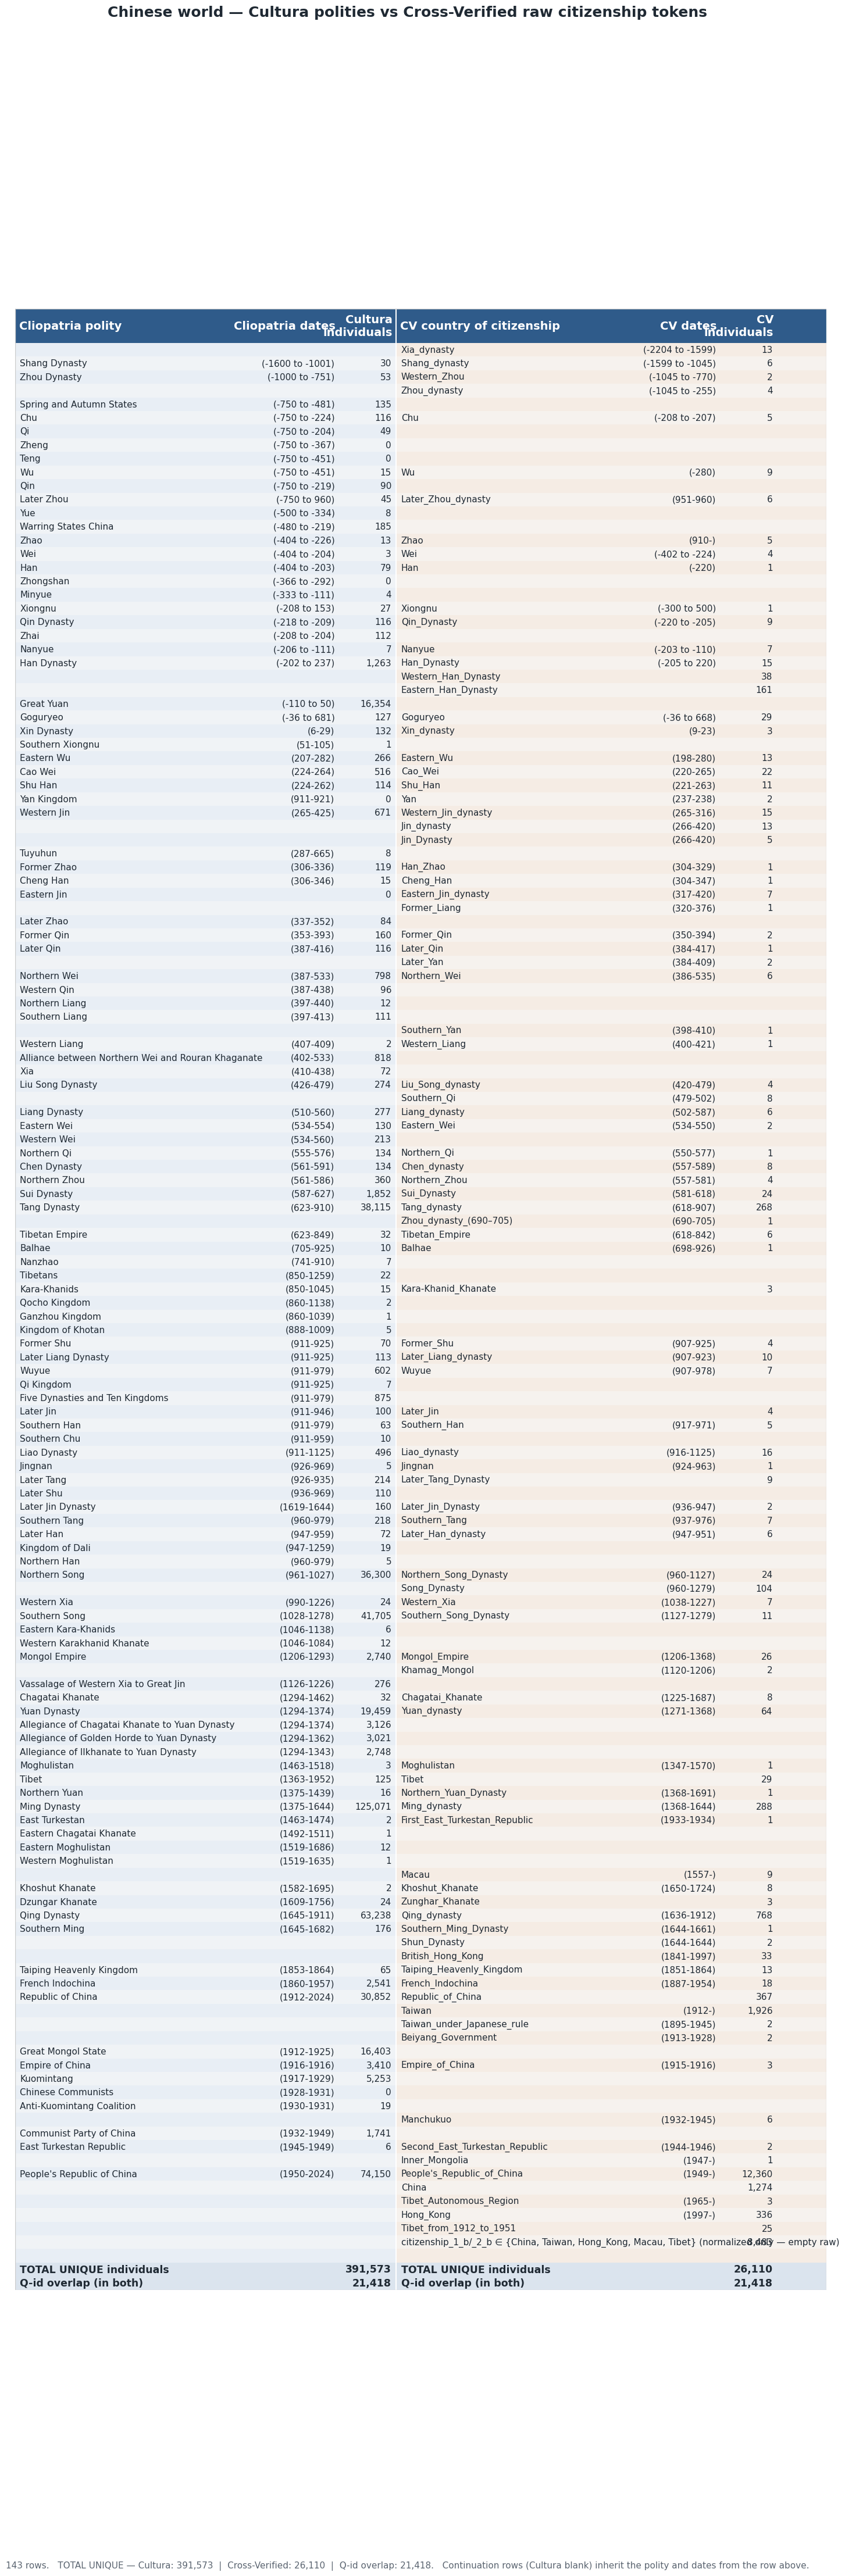

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def _cell(v):
    if v is None:
        return ''
    return f'{v:,}' if isinstance(v, (int, float)) else str(v)

display_rows = [[
    _cell(r['Cliopatria_polity']),
    _cell(r['Cliopatria_dates']),
    _cell(r['Cultura_Individuals']),
    _cell(r['CV_country_of_citizenship']),
    _cell(r['CV_dates']),
    _cell(r['CV_Individuals']),
] for r in table.iter_rows(named=True)]

n_rows = len(display_rows)

# --- Geometry: larger figure for higher publication quality -----------------
ROW_H    = 0.30            # inches per row (was 0.22)
HEADER_H = 0.75            # inches for header band (was 0.55)
FIG_W    = 18              # inches wide (was 14)
FIG_H    = HEADER_H + n_rows * ROW_H + 0.6
DPI_PNG  = 400             # was 200

COL_W = [0.30, 0.10, 0.07, 0.30, 0.10, 0.07]
COL_X = [0.0]
for w in COL_W[:-1]:
    COL_X.append(COL_X[-1] + w)

HEADERS = [
    'Cliopatria polity',
    'Cliopatria dates',
    'Cultura\nindividuals',
    'CV country of citizenship',
    'CV dates',
    'CV\nindividuals',
]

COL_CU      = '#e8eef5'
COL_CV      = '#f5ece4'
ROW_ALT     = '#f8f8f8'
HEADER_FACE = '#2f5b8a'
HEADER_FG   = 'white'
CONT_FG     = '#9aa3ac'
TEXT_FG     = '#1f2933'
TOTAL_FACE  = '#dbe4ee'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'savefig.facecolor': 'white',
    'figure.facecolor':  'white',
    'pdf.fonttype':      42,    # embed TrueType — keeps text crisp at any zoom
    'ps.fonttype':       42,
    'text.antialiased':  True,
})

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 1)
ax.set_ylim(0, n_rows + (HEADER_H / ROW_H))
ax.invert_yaxis()
ax.axis('off')

# Header band
header_y = 0
ax.add_patch(Rectangle((0, header_y), 1, HEADER_H / ROW_H,
                       facecolor=HEADER_FACE, edgecolor='none', zorder=1))
for c, (x, w, label) in enumerate(zip(COL_X, COL_W, HEADERS)):
    ha = 'left' if c in (0, 3) else 'right'
    px = x + 0.005 if ha == 'left' else x + w - 0.005
    ax.text(px, header_y + (HEADER_H / ROW_H) / 2, label,
            ha=ha, va='center', color=HEADER_FG, fontsize=14,
            fontweight='bold', zorder=3)

divider_x = COL_X[3]
ax.plot([divider_x, divider_x],
        [0, n_rows + HEADER_H / ROW_H],
        color='white', lw=1.5, zorder=4)

for i, row in enumerate(display_rows):
    y = (HEADER_H / ROW_H) + i

    is_total = row[0].startswith('TOTAL') or row[0].startswith('Q-id')

    if is_total:
        ax.add_patch(Rectangle((0, y), 1, 1,
                               facecolor=TOTAL_FACE, edgecolor='none', zorder=0.6))
    else:
        ax.add_patch(Rectangle((0, y), divider_x, 1,
                               facecolor=COL_CU, edgecolor='none', zorder=0.5))
        ax.add_patch(Rectangle((divider_x, y), 1 - divider_x, 1,
                               facecolor=COL_CV, edgecolor='none', zorder=0.5))
        if i % 2 == 1:
            ax.add_patch(Rectangle((0, y), 1, 1,
                                   facecolor=ROW_ALT, edgecolor='none', zorder=0.7,
                                   alpha=0.55))

    is_continuation_left  = row[0] == ''
    is_continuation_right = row[3] == ''

    fontsize = 12.5 if is_total else 11.0
    weight   = 'bold' if is_total else 'normal'

    for c, (x, w, val) in enumerate(zip(COL_X, COL_W, row)):
        ha = 'left' if c in (0, 3) else 'right'
        px = x + 0.006 if ha == 'left' else x + w - 0.006
        if c < 3 and is_continuation_left and not is_total:
            color = CONT_FG
        elif c >= 3 and is_continuation_right and not is_total:
            color = CONT_FG
        else:
            color = TEXT_FG
        ax.text(px, y + 0.5, val,
                ha=ha, va='center', color=color, fontsize=fontsize,
                fontweight=weight, zorder=2)

# Outer border
ax.add_patch(Rectangle((0, 0), 1, n_rows + HEADER_H / ROW_H,
                       facecolor='none', edgecolor='#cccccc', lw=1.0, zorder=5))

fig.suptitle('Chinese world — Cultura polities vs Cross-Verified raw citizenship tokens',
             y=0.998, fontsize=18, fontweight='bold', color=TEXT_FG)
fig.text(0.5, 0.001,
         f'{table.height:,} rows.   '
         f'TOTAL UNIQUE — Cultura: {len(all_cu_qids):,}  |  '
         f'Cross-Verified: {len(all_cv_qids):,}  |  '
         f'Q-id overlap: {n_overlap_pre:,}.   '
         'Continuation rows (Cultura blank) inherit the polity and dates from the row above.',
         ha='center', va='bottom', fontsize=11, color='#5a6470')

OUT_PNG = '../data/chinese_world_polity_token_comparison.png'
OUT_PDF = '../data/chinese_world_polity_token_comparison.pdf'
fig.savefig(OUT_PNG, dpi=DPI_PNG, bbox_inches='tight')
fig.savefig(OUT_PDF, bbox_inches='tight')   # vector — sharpest possible
print(f'wrote {OUT_PNG}  ({FIG_W}×{FIG_H:.1f} in @ {DPI_PNG} dpi)')
print(f'wrote {OUT_PDF}  (vector PDF — recommended for paper)')
plt.show()